# Portfolio Opdracht 3: 

# 1. Inleiding

Voor deze opdracht zijn we aangenomen als AI engineers bij VisionWear AI, dit is een technologisch bedrijf dat AI ontwikkeld voor de mode industrie. VisionWear AI werkt samen met webshops, modehuizen en online kleidingplatforms en ontwikkeld hiervoor AI systemen die kleding automatisch kunnen herkennen, beschrijven en nieuwe ontwerpen genereren.

Onze opdracht is om een AI systeem te bouwen dat de volgende dingen kan:

- Kledingstukken automatisch detecteren in afbeeldingen
- Productbeschrijvingen Genereren
- Nieuwe kledingafbeeldingen genereren op basis van tekstuele beschrijvingen. 

VisionWear AI heeft hiervoor een grote dataset verzameld met modefoto's, labels en beschrijvingen, en wij gaan die gebruiken voor de bovenstaande opdracht. We gaan dit doen in 3 delen.
1. Trainen van een model om de kledingstukken en accessoires te identificeren in afbeeldingen.
2. Trainen van een model dat tekstbijschriften te genereren om de kledingstukken te beschrijven.
3. Trainen van een model dat op basis van tekstbijschriften afbeeldingen kan genereren die de kledingstukken beschrijven (met modetermen).

De tekst uit deze opdracht wordt in het engels gegenereerd.

# Setup en Data Inladen

In [19]:
import os

# Voor een stabiele config van cuda en pytorch,
# gebruik ik deze environment variables om problemen 
# met cuda libraries en log levels te voorkomen.
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Dank aan deze stackoverflow post die uitlegde ik fatsoenlijk mn cuda libraries moest linken,
# BRON: https://stackoverflow.com/questions/13428910/how-to-set-the-environment-variable-ld-library-path-in-linux 
#os.environ['LD_LIBRARY_PATH'] = '/usr/lib:/opt/cuda/targets/x86_64-linux/lib'

import torch
import nlpaug.augmenter.word as naw


# Zet cuDNN benchmarking en determinisme tijdelijk zo dat hij de mismatch negeert
#torch.backends.cudnn.benchmark = False
#torch.backends.cudnn.deterministic = True


from transformers import (
    pipeline, 
    AutoTokenizer, 
    AutoModelForSequenceClassification, 
    Trainer, 
    TrainingArguments, 
    AutoConfig,
    DataCollatorWithPadding,
    AutoModelForMaskedLM
)

print(f"Pytorch CUDA beschikbaar: {torch.cuda.is_available()}")

Pytorch CUDA beschikbaar: False


In [ ]:
# Inladen van libraries
# iets in de volgorde zorgt ervoor dat er geen problemen zijn met cuda libraries,
# dus laat de volgorde zo staan AUB.
import cv2
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import shutil
import yaml
import cv2
from pathlib import Path
from ultralytics import YOLO

from matplotlib import patches
from datasets import load_dataset



In [21]:
# En stellen hier een random state variable in, hierdoor blijven onze splits, 
# maar ook de modellering die daarbij komt kijken consistent met een set seed.
def set_seeds(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    # Voor volledige GPU determinisme (waarschuwing: kan training vertragen)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'

set_seeds(65)

RANDOM_STATE = 42

pd.set_option('display.max_columns', None)

In [ ]:
import os, yaml, shutil, cv2
from pathlib import Path
from ultralytics import YOLO

import os, yaml, shutil, cv2
from pathlib import Path
from ultralytics import YOLO

# 1. PADEN DEFINIËREN





In [ ]:
BASE_DIR = Path.cwd()

TRAIN_DIR = BASE_DIR / "Train"
TEST_DIR = BASE_DIR / "Test"

train_images_dir = TRAIN_DIR / "images"
train_labels_dir = TRAIN_DIR / "labels"

test_images_dir = TEST_DIR / "images"

DATA_DIR = Path("/home/beef/Downloads/karaoke-k-klassificatie-2026/Deep-Learning-3")
ORIGINAL_IMAGES = DATA_DIR / "Train/images"
ORIGINAL_LABELS = DATA_DIR / "Train/labels"


BASE_PROJECT_DIR = Path("/home/beef/Downloads/models_run")




BASE_PROJECT_DIR = Path("/home/beef/Downloads/models_run")
DATA_DIR = Path("/home/beef/Downloads/karaoke-k-klassificatie-2026/Deep-Learning-3")
IMAGES_DIR = DATA_DIR / "Train/images"
LABELS_DIR = DATA_DIR / "Train/labels"

GENERALIST_IDS = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] 
CLOTHING_LABELS = ["sunglass", "hat", "jacket", "shirt", "pants", "shorts", "skirt", "dress", "bag", "shoe"]


In [24]:
# Hier maken wij de dataset aan die we gaan gebruiken voor de analyse en training
# we pakken heirbij de locatie van de images en de bijpassende labels,
# die lcoaties voegen we toe aan de df.

# Daarna pakken we de label die met de corresponderende box en de afbeelding waarin die box staat
# en voegen die ook toe.
parsed_data = []

for img_path in train_images_dir.glob("*"):
    if img_path.suffix.lower() not in [".jpg"]:
        continue

    label_path = train_labels_dir / f"{img_path.stem}.txt"

    with open(label_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for line in lines:
        
        parts = line.strip().split()
        if len(parts) == 5:
            parsed_data.append(
                {
                    "image_path": str(img_path),
                    "label_path": str(label_path),
                    "image_name": img_path.name,
                    "class_id": int(parts[0]),
                    "center_x": float(parts[1]),
                    "center_y": float(parts[2]),
                    "width": float(parts[3]),
                    "height": float(parts[4]),
                }
            )

train_df = pd.DataFrame(parsed_data)
display(train_df.head(1))

,image_path,label_path,image_name,class_id,center_x,center_y,width,height
0,/home/beef/Documents/GitHub/Deep-Learning-3/Tr...,/home/beef/Documents/GitHub/Deep-Learning-3/Tr...,1.jpg,8,0.68875,0.639167,0.3025,0.118333


In [25]:
# Hier beginnen we met een korte analyse van de dataset, 
# we kijken naar de dimensies van het dataframe,
print(f"Dimensies van het DataFrame: {train_df.shape}")
# Het aantal unieke images binnen de dataset,
# aangezien er meerdere boxes per afbeelding kunnen zijn.
amount_imgs = train_df["image_name"].nunique()
print("Aantal unieke afbeeldingen:", amount_imgs)
# En als laatste het aantal missende waardes per kolom
print(f"Aantal null waarden per kolom:\n{train_df.isnull().sum()}")


Dimensies van het DataFrame: (8298, 8)
Aantal unieke afbeeldingen: 2145
Aantal null waarden per kolom:
image_path    0
label_path    0
image_name    0
class_id      0
center_x      0
center_y      0
width         0
height        0
dtype: int64


**Analyse**
Uiteindelijk zien we hierboven dat:
- Er geen waardes missen binnen de numerieke kolommen
- Er meer rijen in de dataset zijn dan images, dit duidt dus op het feit dat er meerdere boxes zijn per image.

Hieronder een korte samenvatting van de gehele dataset:

**Train_DF en Train Image Files:**
- train_df shape = (8298, 8)
- Aantal train image files op schijf: 2145

| Kolomnaam | Uitleg | 
| -| -|
| image_path| Bevat het pad naar de image file | 
|label_path | Bevat het pad naar het txtbestand met de afmetingen voor de image | 
| image_name| Bevat de naam van het corresponderende image file | 
| class_id| Bevat de numerieke categorie van het clothing item|
| center_x| Bevat het centrale x coordinaat van de bounding box |
| center_y| Bevat het centrale y coordinaat van de bounding box|
| width| Bevat de breedte van de bounding box|
| height| Bevat de hoogte van de bounding box|



# 2. EDA

Hieronder beginnen we met de EDA, hier gaan we vooral kijken naar de bounding boxes en hoevaak ze voorkomen per image.

In [26]:
# Hier hebben we vaste kleuren ingesteld voor de kledingsstukken, 
# zodat alles consistent blijft qua overzicht en graphics.
clothing_colors = {
    'sunglass': "#ff0000",  
    'hat': "#ff7b00",
    'jacket': "#a29a00", # keb geel donkerder gemaakt, anders was de witte txt niet te zien
    'shirt': "#b7ff00",  
    'pants': "#00FF6A",   
    'shorts': "#00ffe5",  
    'skirt': "#0000ff",     
    'dress': "#6f00ff",
    'bag': "#d400ff", 
    'shoe': "#ff0090"}

# En hier hebben we een mapping van class_id's naar labels, 
# zodat we makkelijk kunnen zien welke class_id bij welk kledingstuk hoort.
clothing_labels = {
    0: "sunglass",
    1: "hat",
    2: "jacket",
    3: "shirt",
    4: "pants",
    5: "shorts",
    6: "skirt",
    7: "dress",
    8: "bag",
    9: "shoe",
}

# Dan linken we de class_id's aan de class_names, 
# zodat we makkelijk kunnen zien welke class_id bij welk kledingstuk hoort.
train_df['class_name'] = train_df['class_id'].map(clothing_labels)

## 2.1. Aantal Kledingstukken per Foto

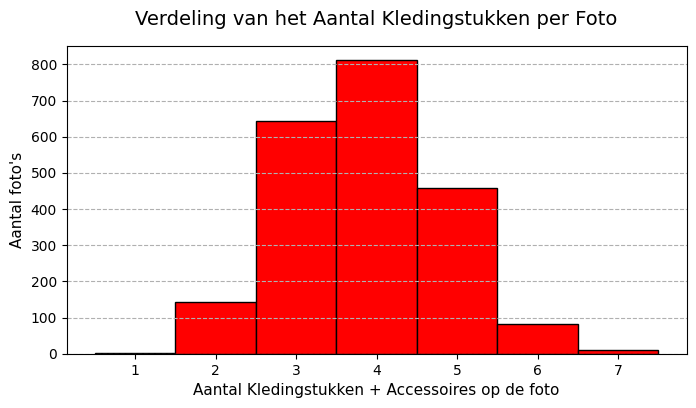

In [27]:
# We beginnen met een simpele analyse van de dataset, 
# namelijk de verdeling van het aantal kledingstukken per foto.
df_summary = train_df.groupby('image_name').agg(totaal_tags=('class_id', 'count')).reset_index()

# De min en max
max_stukken = df_summary['totaal_tags'].max()
min_stukken = df_summary['totaal_tags'].min()


# En dan een simpele barchart voor de eerste visual
plt.figure(figsize=(8, 4))
sns.histplot(
    data=df_summary, 
    x='totaal_tags', 
    discrete=True, 
    color="#ff0000", 
    alpha=1)

plt.title('Verdeling van het Aantal Kledingstukken per Foto', fontsize=14, pad=15)
plt.xlabel('Aantal Kledingstukken + Accessoires op de foto', fontsize=11)
plt.ylabel('Aantal foto\'s', fontsize=11)
plt.xticks(range(int(min_stukken), int(max_stukken) + 1))
plt.grid(axis='y', linestyle='--', alpha=1)

plt.show()

**Analyse:**

We zijn begonnen naar het aantal kledingstukken die voorkomen per foto.

Hierboven zien we die dus, we zien hier niets onverwachts. De meeste foto's hebben tussen de 3 en 5 kledingstukken, en zoals later gezien wordt zijn niet alle kledingstukken gelabeld dus dit leidt verder niet tot nieuwe inzichten. 

Toch zijn er een paar foto's met een enkel kledingstuk, en waarschijnlijk zijn er geen images van mensen met een enkel kledingstuk, en zoals we later zien missen er hier en daar gewoon een paar boxes.

## 2.2. Aantal Kledingssoorten Aanwezigheid

We gaan hieronder verder met de analyse door te kijken naar de aanwezigheid van alle kledingstukken, dat gaan we hieronder nogmaals doen met een simpele barchart.

shoe        : 2081
shirt       : 1486
bag         : 1188
jacket      : 777
skirt       : 697
dress       : 550
pants       : 508
shorts      : 395
sunglass    : 343
hat         : 273


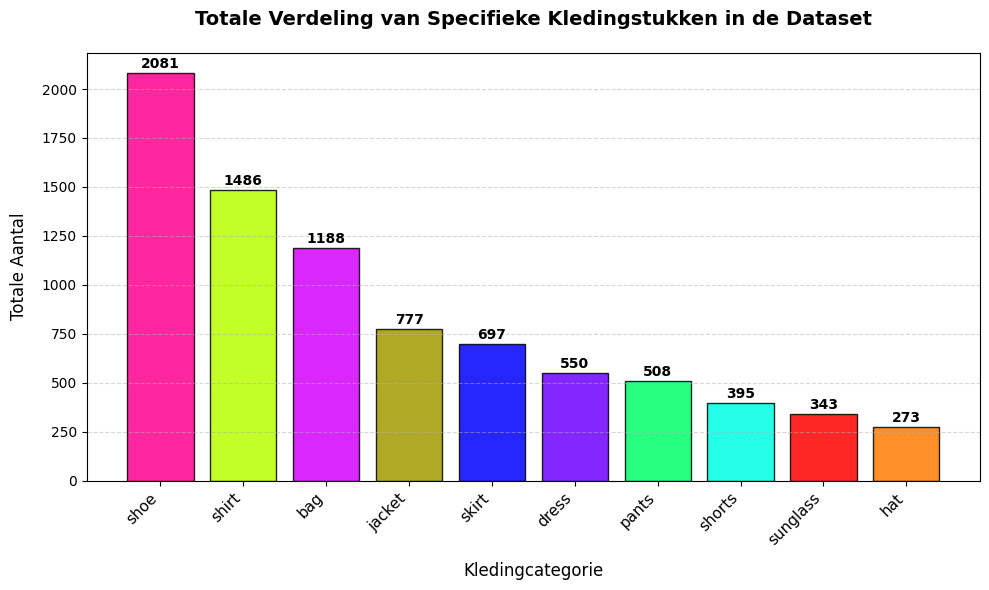

In [28]:
# Nu gaan we kijken naar de verdeling van de specifieke kledingstukken in de dataset,
# Hierbij kijken we gewoon naar value counts en plotten deze 
counts = train_df['class_name'].value_counts()

for name in counts.index:
    print(f"{name.ljust(12)}: {str(counts[name])}")


plot_colors = [clothing_colors.get(name, "#333333") for name in counts.index]

plt.figure(figsize=(10, 6))

bars = plt.bar(counts.index, counts.values, color=plot_colors, edgecolor='black', alpha=0.85)


for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        yval + 10, 
        f'{int(yval)}', 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        weight='bold'
    )

plt.title('Totale Verdeling van Specifieke Kledingstukken in de Dataset', fontsize=14, pad=20, weight='bold')
plt.xlabel('Kledingcategorie', fontsize=12, labelpad=10)
plt.ylabel('Totale Aantal', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Analyse:**

Zoals we hierboven zien zijn de verschillende kledingstukken en accessoires niet gelijk verdeeld over de dataset. We zien dat schoenen veruit het meest voorkomen, maar dit is ook logisch aangezien er van de overige categorieen geen alternatief is voor shoes, bevalve barefoot maar dat is geen categorie.

Verder zien we ook dat van de accesoiries dat bag veruit het meest voorkomt, daarna pas sunglasses en hats. 

Maar dit geeft uiteindelijk een oneerlijk beeld van de representatie van de kledingstukken, daarom gaan we het hieronder groeperen.

### 2.2.1. Kledinstukken Gegroepeerd op Categorie

Hieronder gaan we dus nogmaals de verdelingen plotten, maar deze keer groeperen we ze op de algemene plek op het lichaam waar ze horen.

In [29]:
# We groeperen de kledingstukken in hoofdgroepen, 
# zodat we een beter overzicht krijgen van de verdeling 
# van de verschillende soorten kledingstukken.
# Dress hebben we hier zometeen dubbel omdat het functioneert als legs als torso.
hoofdgroepen_mapping = {
    'pants': 'Legwear',
    'shorts': 'Legwear',
    'skirt': 'Legwear',
    'shirt': 'Torsokleding',
    'bag': 'Accessoires',
    'sunglass': 'Accessoires',
    'hat': 'Accessoires',
    'shoe': 'Footwear',
    'jacket': 'Outerwear'}

# Copy make voor edits
plot_df = train_df.copy()

# Dan linken we de hoofdgroepen aan de class_names
plot_df['hoofdgroep'] = plot_df['class_name'].map(hoofdgroepen_mapping).fillna('Overig')

# En dresses dubbel
dresses = plot_df[plot_df['class_name'] == 'dress'].copy()

# En dan alles toevoegen aan een df
if not dresses.empty:
    dresses_torso = dresses.copy()
    dresses_torso['hoofdgroep'] = 'Torsokleding'
    
    dresses_legwear = dresses.copy()
    dresses_legwear['hoofdgroep'] = 'Legwear'
    
    plot_df = plot_df[plot_df['class_name'] != 'dress']
    
    plot_df = pd.concat([plot_df, dresses_torso, dresses_legwear], ignore_index=True)

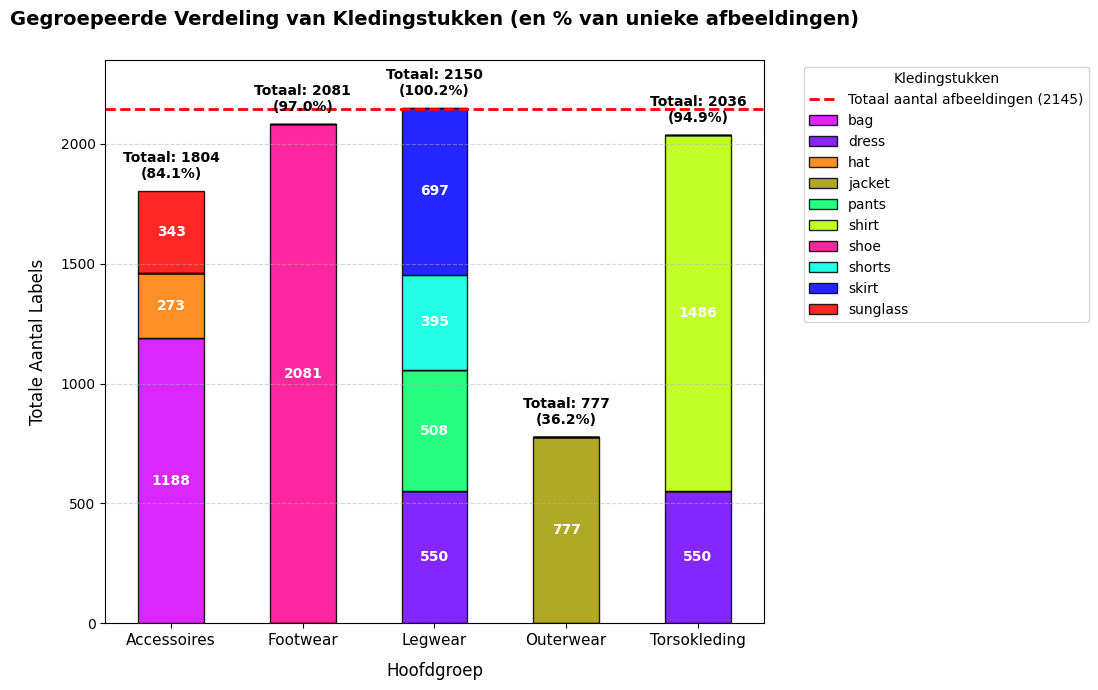

In [30]:
# Dan gaan we hier de verdeling van de hoofdgroepen plotten,
grouped_data = pd.crosstab(plot_df['hoofdgroep'], plot_df['class_name'])
current_columns = grouped_data.columns

# en hier halen we de kleuren op voor de huidige class_names
plot_colors = [clothing_colors.get(name, "#333333") for name in current_columns]


fig, ax = plt.subplots(figsize=(11, 7))  
grouped_data.plot(kind='bar', stacked=True, color=plot_colors, edgecolor='black', alpha=0.85, ax=ax)

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 0:
        ax.text(
            x + width/2, 
            y + height/2,  
            f'{int(height)}', 
            ha='center', 
            va='center', 
            fontsize=10, 
            weight='bold',
            color='white'  
        )

# Nog een rode lijn voor het totaal aantal afbeeldingen, 
# zodat we kunnen zien hoeveel afbeeldingen er zijn in vergelijking met het aantal labels,
# per lichaamsdeel
ax.axhline(
    y=amount_imgs, 
    color='red', 
    linestyle='--', 
    linewidth=2, 
    label=f'Totaal aantal afbeeldingen ({amount_imgs})' )

# En hier voegen we de totale aantallen en percentages toe boven elke bar,
# zodat we kunnen zien hoeveel labels er zijn per hoofdgroep,
for i, total in enumerate(grouped_data.sum(axis=1)):
    percentage = (total / amount_imgs) * 100
    
    ax.text(
        i, 
        total + (grouped_data.values.max() * 0.02),  
        f'Totaal: {int(total)}\n({percentage:.1f}%)', 
        ha='center', 
        va='bottom', 
        weight='bold', 
        fontsize=10)
    
plt.title('Gegroepeerde Verdeling van Kledingstukken (en % van unieke afbeeldingen)', fontsize=14, pad=25, weight='bold')
plt.ylabel('Totale Aantal Labels', fontsize=12, labelpad=10)
plt.xlabel('Hoofdgroep', fontsize=12, labelpad=10)
plt.xticks(rotation=0, fontsize=11) 

# En nog een hoger limiet voor een nette graph
ax.set_ylim(0, grouped_data.sum(axis=1).max() + 200)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title="Kledingstukken", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

Als we alleen zouden kijken naar de categorieen los van elkaar zien we een heel scheve verdeling, maar als we hieronder zouden kijken naar de kledingstukken gegrrpepeerd op de kledingscategorie waar ze bij behoren zien we een heel ander verhaal:

- Legwear
    - Pants
    - Shorts
    - Skirt
- Torsokleding
    - Dress
    - Shirt
- Accesseroires
    - Bag
    - Sunglasses
    - Hat
- Footwear
    - Shoes
- Outerwear
    - Jacket


We hebben hierbij ook dress bij legwear en torsokleding gezet, dresses functioneren als beide en als deze ontbrak uit een van de 2, zou dat duiden op mensen zonder broek en/of shirt.

Verder zien we dat outerwear/jacket veruit het minste is, maar ook logisch aangezien deze naast accesoires de optionele kledingstuk is, verder kan de vage definitie van jacket ook de uitleg zijn voor de dip die we zien bij torsokleding.

Verder uit accessoires zien we dat bags veruit het meeste voorkomen.

Hierbij is het opvallendste de missende schoenen en om daar inzicht in te krijgen gaan we in dit volgende hoofdstuk kijken naar de image data en de boxes in de foto's.

## 2.3. Fotos

In dit deel van de EDA gaan we de images analyseren en ook de boxes binnen die images analyseren.

We beginnen hieronder met de image sizes.

In [31]:
# Voor elke image in de Train en Test directories
# lezen we de images in met OpenCV en pakken de unieke resoluties
def check_sizes(dir_path):
    return {cv2.imread(str(f)).shape[:2] for f in dir_path.glob("*.jpg")}

# En de funtie toepassen op de directories
train_sizes = check_sizes(train_images_dir)
test_sizes = check_sizes(test_images_dir)
print(f"Train formaten: {train_sizes}")
print(f"Test formaten: {test_sizes}")

Train formaten: {(600, 400)}
Test formaten: {(600, 400)}


**Analyse:**

We zien hierboven dat alle images dezelfde afmetingen hebben (600 x 400 pixels), we hoeven dus bij later modelleren alleen de verhouding van 3 tot 2 in gedachte houden, maar niet verschillende afmetingen.

### 2.3.1. Subboxes per Image

In [32]:
# Hieronder 3 aparte functies om de absolute breedte, hoogte en oppervlakte 
# van de bounding boxes te plotten
def plot_absolute_width_horizontal(df, images_dir):
    plot_df = df.copy()
    
    img_dims = {f.name: cv2.imread(str(f)).shape[1] for f in images_dir.glob("*.jpg") if cv2.imread(str(f)) is not None}
    plot_df['abs_width'] = plot_df['width'] * plot_df['image_name'].map(img_dims)
    
    order = plot_df.groupby("class_name")["abs_width"].median().sort_values(ascending=False).index

    # Plotten
    plt.figure(figsize=(10, 8))
    sns.boxplot(
        data=plot_df, 
        x="abs_width", 
        y="class_name", 
        order=order, 
        palette=clothing_colors, 
        hue="class_name", 
        orient='h'
    )
    
    plt.title("Absolute Breedte per Categorie in Pixels", fontsize=14, weight='bold')
    plt.xlabel("Breedte in Pixels")
    plt.ylabel("Kledingcategorie")
    plt.grid(axis="x", linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()


def plot_absolute_height_vertical(df, images_dir):
    plot_df = df.copy()
    img_dims = {f.name: cv2.imread(str(f)).shape[0] for f in images_dir.glob("*.jpg") if cv2.imread(str(f)) is not None}
    plot_df['abs_height'] = plot_df['height'] * plot_df['image_name'].map(img_dims)
    
    order = plot_df.groupby("class_name")["abs_height"].median().sort_values(ascending=False).index

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=plot_df, x="class_name", y="abs_height", order=order, 
                palette=clothing_colors, hue="class_name", legend=False)
    plt.title("Absolute Hoogte per Categorie in Pixels", fontsize=14, weight='bold')
    plt.ylabel("Hoogte in Pixels")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()

def plot_absolute_area_vertical(df, images_dir):
    plot_df = df.copy()
    img_dims = {f.name: (cv2.imread(str(f)).shape[1], cv2.imread(str(f)).shape[0]) 
                for f in images_dir.glob("*.jpg") if cv2.imread(str(f)) is not None}
    
    plot_df[['img_w', 'img_h']] = plot_df['image_name'].map(img_dims).tolist()
    plot_df["abs_area"] = (plot_df["width"] * plot_df["img_w"]) * (plot_df["height"] * plot_df["img_h"])
    
    order = plot_df.groupby("class_name")["abs_area"].median().sort_values(ascending=False).index

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=plot_df, x="class_name", y="abs_area", order=order, 
                palette=clothing_colors, hue="class_name", legend=False)
    plt.title("Totaal aantal Pixels per Categorie", fontsize=14, weight='bold')
    plt.ylabel("Oppervlakte in Pixels")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.show()





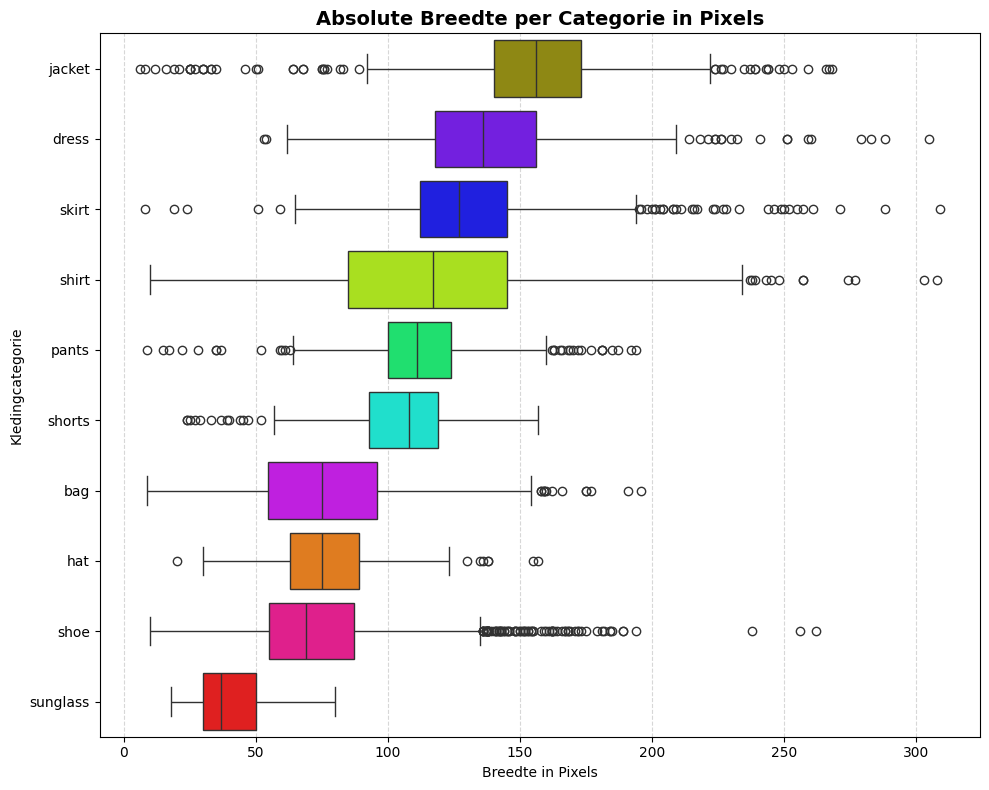

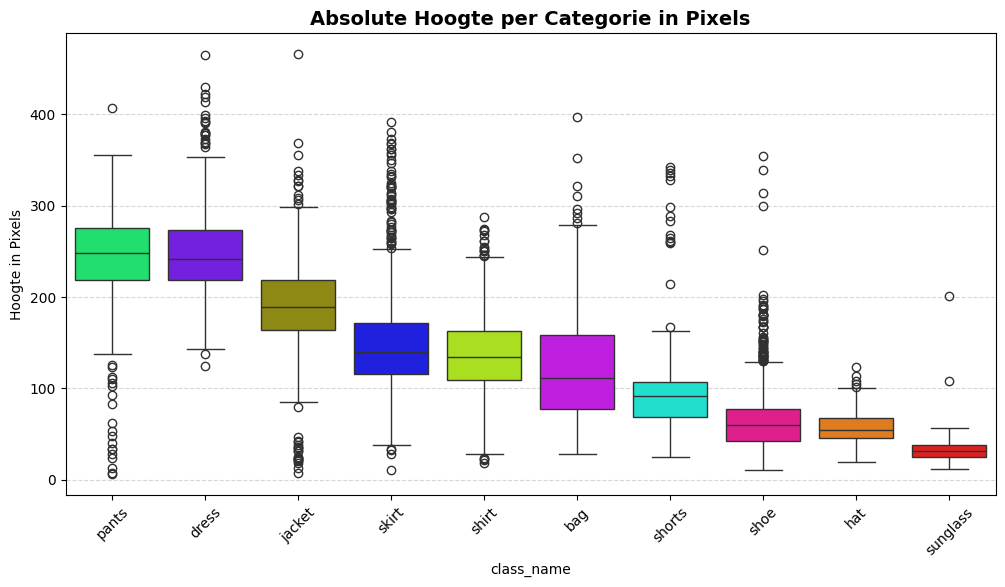

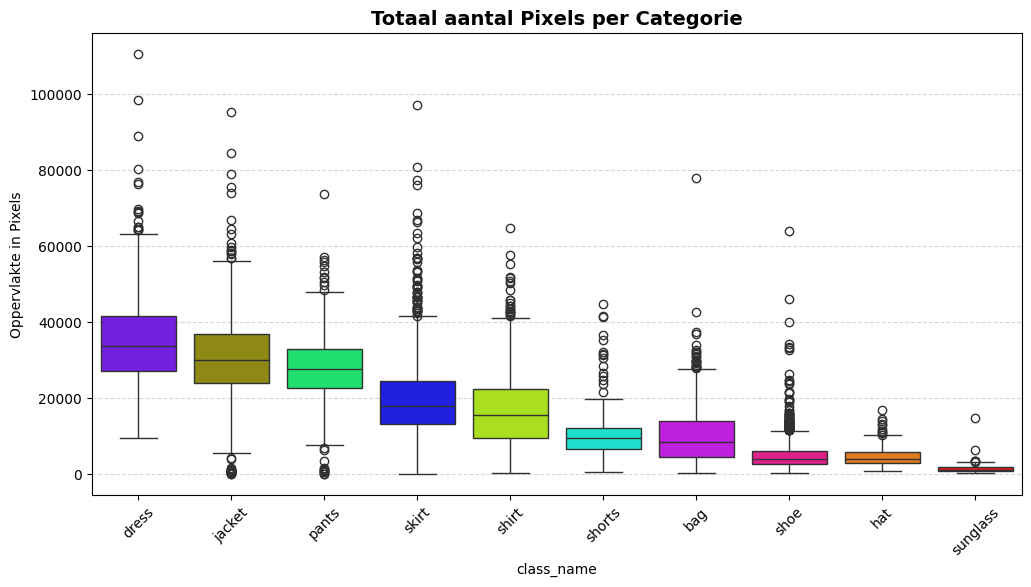

In [33]:
plot_absolute_width_horizontal(train_df, train_images_dir)
plot_absolute_height_vertical(train_df, train_images_dir)
plot_absolute_area_vertical(train_df, train_images_dir)

**Analyse:**

- Dress
    - Qua oppervlakte in pixels is de dress het grootst, verder zien we ook bij breedte en lengte dat hij rond de top staat. Als we kijken naar de representatie binnen de dataset (550 van de x), kunnen we aannemen dat er genoeg pixels zijn voor het model om dresses goed te voorspellen.
- Jacket 
    - Voor jacket geld eigenlijk precies hetzelfde als voor dress, hoewel de jacket over het algemeen breder en korter is dan de dress. Verder heeft deze ook meer representatie (777 van de ), we kunnen dus nogmaals aannemen dat we voldoende images hebben met Jackets.
- Pants
    - Nogmaals voor pants gelden dezelfde voorwaarden als de bovenstaande 2, hij bevat een goed totaal aantal pixels in combinatie met een goede representatie (508 van de ), dus nogmaals de voorspelling dat we genoeg data hebben.
- Skirt
    - Skirt zit over het algemeen in het midden over meerdere categorieeen. Het bevat een goed aantal totale pixels en een goede representatie binnen de trainset (), en zal waarschijnlijk geen probleem zijn.
- Shirt
    - Shirt is vrij similair to Skirt, ze hebben allebei een vergelijkbaar totaal aantal pixels, hoewel de spreiding van shirt hoger is bij breedte. Toch heeft shirt een stuk meer representatie (), maar zal waarschijnlijk niet leiden tot problemen.
- Shorts
    - In vergelijking met bag hieronder bevatten de shorts images meer totale pixels dan bag, maar de representatie is vrij laag in vergelijking met bag, dit wordt dus een aandachtspunt en we moeten in de gaten houden hoe deze performt bij het trainen.
- Bag
    - Bags zitten een beetje in het midden, de totale pixelcount is niet al te hoog, maar bevat een goede hoeveelheid aan representatie in de trainset en zal daarom waarschijnlijk niet leiden tot problemen.
- Shoe
    - Shoes bevatten dezelfde problemen als hats en sunglasses hieronder, toch heeft deze een groot voordeel, zijn gigantische aanwezigheid in representatie (), hoewel ze vaak uit weinig totale pixels bestaan zal het waarschijnlijk mogelijk zijn om ze goed te kunnen voorspellen omdat er zoveel representatie is.
- Hat
    - Zoals hieronder sunglasses ook heeft heeft hat een lage totale pixelcount en ook een lage representatie (), zoals we later ook zien bij het visualiseren van de boxes. Zit de hoed ook vaak naar achter getrokken, het zal waarschijnlijk moeilijk zijn om voor modellen te voorspellen wat een hoed is of gewoon een grote bos haar.
- Sunglasses
    - Dit is de accesoire met de minste aanstal pixels per box, daarnaast is het de op een na minst voorkomende kledingcategorie in onze dataset (343 van de ), waarschijnlijk zullen we hierom dus problemen gaan ervaren aangezien we weinig data hebben in representatie en totaal aantal beschikbare pixels. Toch een kleine toevoeging, in zonnenbrillen zit weinig variation, het zijn 2 donkere afgeronde vierkanten op het hoofd dus misschien valt het toch wel mee.

Zoals hierboven genoemd zullen we waarschijnlijk problemen ervaren rondom hats en sunglasses, beide voor hun lage representatie en laag totaal aantal pixels

### 2.3.2. Subboxes Plotten 

In [34]:
# Hieronder plotten we 4 random images,
# zodat we ze kunnen scannen voor anomalies.
def plot_fashion_grid(df):
    unique_images = df["image_name"].unique()
    chosen_images = np.random.choice(unique_images, size=4, replace=False)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))
    axes = axes.flatten()  
    
    for i, image_name in enumerate(chosen_images):
        ax = axes[i]
        
        img_objects = df[df["image_name"] == image_name]
        
        img_path = img_objects.iloc[0]['image_path']
        
        image = cv2.imread(img_path)
        img_h, img_w, _ = image.shape
        
        ax.imshow(image)
        
        for _, row in img_objects.iterrows():
            c_name = row["class_name"]
            box_color = clothing_colors.get(c_name, "#FFFFFF")
            
            w = row["width"] * img_w
            h = row["height"] * img_h
            xmin = (row["center_x"] - row["width"] / 2) * img_w
            ymin = (row["center_y"] - row["height"] / 2) * img_h
            
            rect = patches.Rectangle(
                (xmin, ymin),
                w,
                h,
                linewidth=2.0,
                edgecolor=box_color,
                facecolor="none",
            )
            ax.add_patch(rect)
            
            text_color = "black" if c_name in ["shirt", "shorts"] else "white"
            
            ax.text(
                xmin,
                ymin - 8 if ymin - 8 > 0 else ymin + 15,  
                f" {c_name.upper()} ",
                color=text_color,
                fontsize=8,
                weight="bold",
                bbox=dict(facecolor=box_color, edgecolor=box_color, alpha=0.85, pad=1),
            )
        
        ax.set_title(f"{image_name}", fontsize=11, pad=5)
        ax.axis("off")
        
    plt.suptitle("EDA Visualisatie: 2x2 Kleding Grid", fontsize=18, weight="bold", y=0.95)
    plt.tight_layout()
    plt.show()

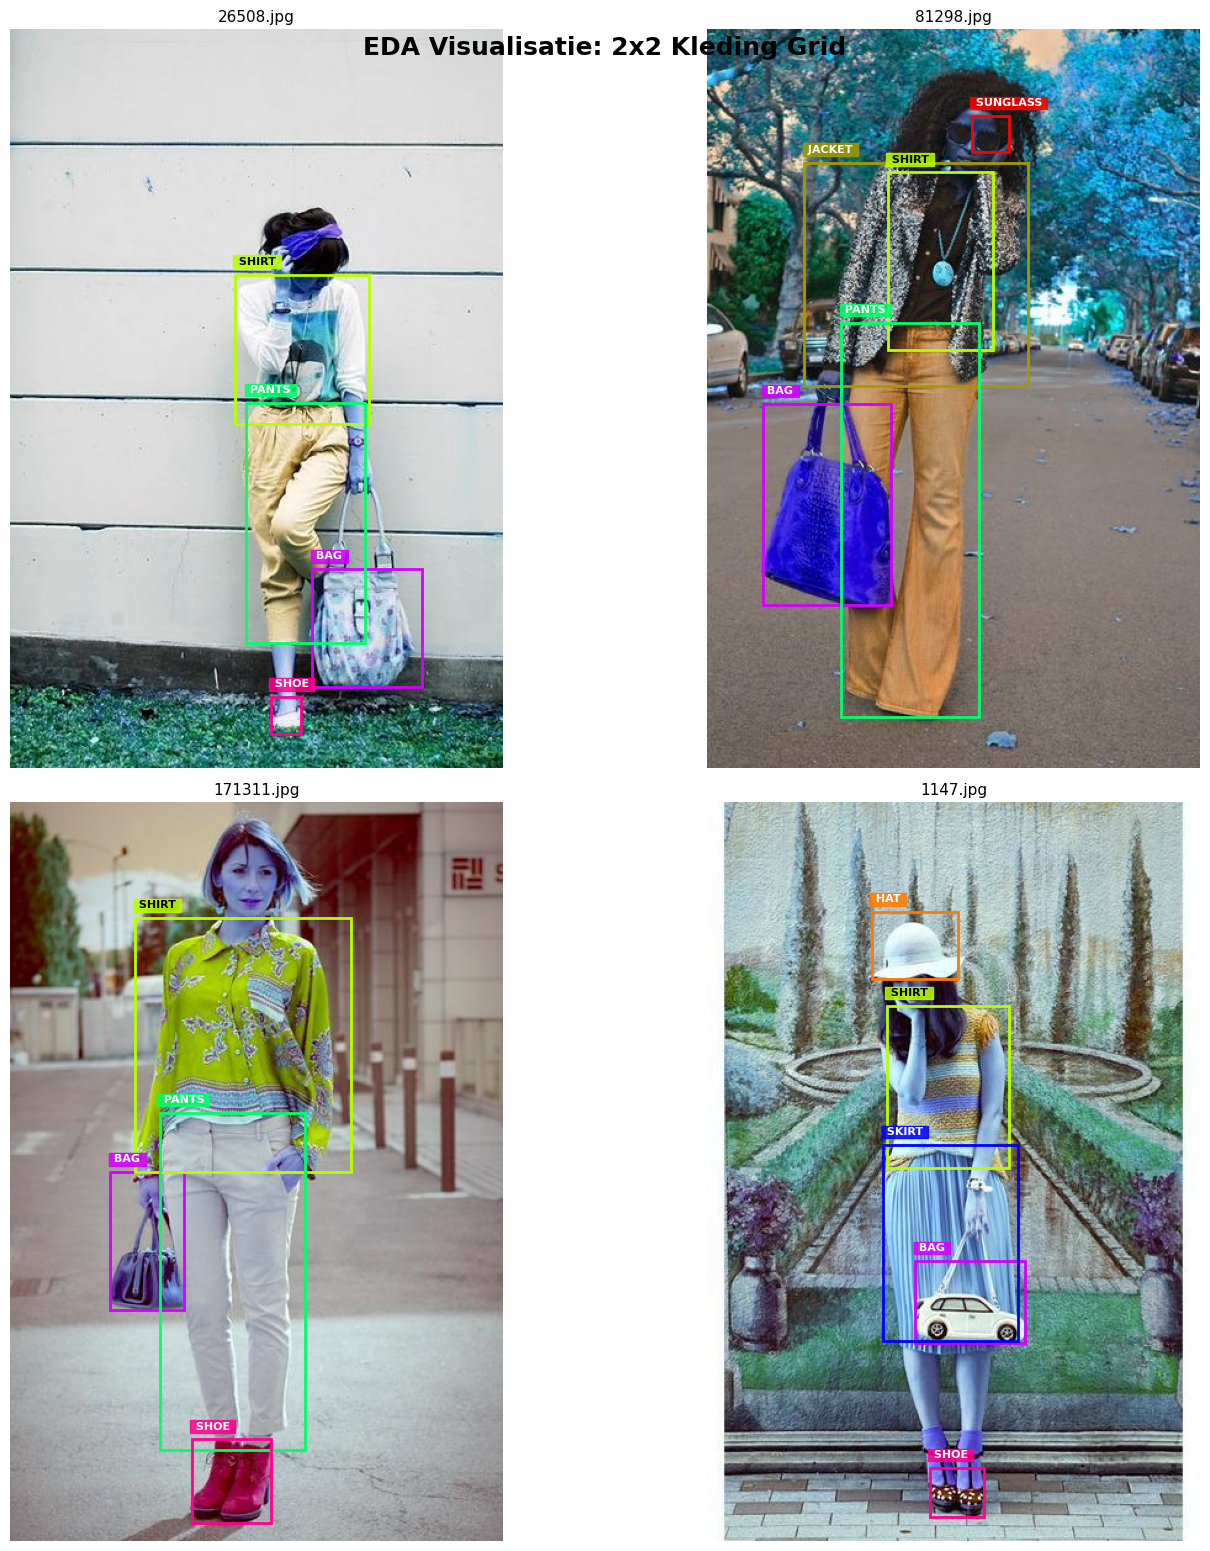

In [37]:
plot_fashion_grid(train_df)

### 2.3.3. Boxes Anomalies

Zoals hierboven dus te zien is bevatten de meeste fotos meerdere delen van de afbeeldingen die een kledingsstuk bevatten.

1. Anomalies en Fouten

Toch zagen we bij kort browsen door de images een paar anomalies zoals hieronder te zien zijn, zoals sunglasses met 1 glas en een paar mislabeled stukken clothing.

<img src="nosunglass 2.png" width="400">
<br>

<img src="nosunglass.png" width="400">
<br>

<img src="nojacket.png" width="400">
<br>

<img src="nobag.png" width="400">
<br>

2. Shoeless:

Verder zagen we dat er verassend weinig shoes waren voor wat de verwachting was. Zoals hieronder te zien waren er een paar images waar schoenen in zaten, maar geen box er om heen. Dit is uiteindelijk geen probleem want we hebben meer dan genoeg data, maar wel een observatie.

<img src="susanshoeless1.png" width="400">
<br>

<img src="susanshoeless2.png" width="400">
<br>


Ook zagen we hier een daar wat watermarks, ook door de boxes van de kledingsstukken heen, gelukkig was dit bij de random images die wij bekeken hadden heel zeldzaam, maar het is een aandachtspunt.

Het is voor ons niet mogelijk om deze te cleanen want het zijn 2145 images. Dus moeten we het model iets aan de algemenere kant houden zodat hij niet overgetraind wordt op foutieve images.


In [36]:
aaaaa

NameError: name 'aaaaa' is not defined

# Opdracht 2: Objectdetectie
 In deze deelopdracht werk je uitsluitend met de images en labels uit de data voor
deel 1. Bouw en train een objectdetectie model om de tien klassen kleding en
modeaccessoires in de dataset te detecteren en hun locaties te voorspellen met
behulp van bounding-boxes.

 Beschrijf in je eigen woorden hoe je model voorspellingen doet.

 Beschrijf hoe je de afbeeldingen voorbewerkt.

 Beschrijf in detail welke stappen, indien aanwezig, je onderneemt voor feature
engineering.

 Onderbouw je keuzes van de hyperparameters, de keuze van de optimizer en het
aantal trainingsepochs.

 Beschrijf de lossfunctie voor dit model in je eigen woorden en hoe deze werk

# 3 Modelleren



In [ ]:


def prepare_ultimate_generalist():
    dataset_root = BASE_PROJECT_DIR / "ultimate_generalist_dataset"
    if dataset_root.exists(): shutil.rmtree(dataset_root)
    (dataset_root / "train/images").mkdir(parents=True, exist_ok=True)
    (dataset_root / "train/labels").mkdir(parents=True, exist_ok=True)

    
    for label_path in LABELS_DIR.glob("*.txt"):
        img_path = IMAGES_DIR / f"{label_path.stem}.jpg"
        if not img_path.exists(): continue
        
        img = cv2.imread(str(img_path))
        with open(label_path, 'r') as f:
            lines = [l.split() for l in f.readlines() if int(l.split()[0]) in GENERALIST_IDS]
        
        if lines:
            shutil.copy(img_path, dataset_root / "train/images" / img_path.name)
            with open(dataset_root / "train/labels" / label_path.name, 'w') as f:
                for l in lines:
                    new_cls = GENERALIST_IDS.index(int(l[0]))
                    f.write(f"{new_cls} {' '.join(l[1:])}\n")
            
            flipped_img = cv2.flip(img, 1)
            cv2.imwrite(str(dataset_root / "train/images" / f"flip_{img_path.name}"), flipped_img)
            with open(dataset_root / "train/labels" / f"flip_{label_path.name}", 'w') as f:
                for l in lines:
                    new_cls = GENERALIST_IDS.index(int(l[0]))
                    xc, yc, w, h = map(float, l[1:])
                    f.write(f"{new_cls} {1.0 - xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")

    yaml_path = BASE_PROJECT_DIR / "ultimate_generalist.yaml"
    with open(yaml_path, "w") as f:
        yaml.dump({
            "path": str(dataset_root), "train": "train/images", "val": "train/images", 
            "nc": len(CLOTHING_LABELS), "names": CLOTHING_LABELS
        }, f)

    model = YOLO("yolo26n.pt")
    model.train(data=str(yaml_path), 
                epochs=150, 
                dropout=0.3,
                imgsz=576, 
                project=str(BASE_PROJECT_DIR), 
                name="ultimate_gen_mirror")

prepare_ultimate_generalist()

🔄 Dataset voorbereiden (alles in 1) met mirroring...
New https://pypi.org/project/ultralytics/8.4.62 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3080 Ti, 11910MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/beef/Downloads/models_run/ultimate_generalist.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.3, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=576, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det

# 4. HM

In dit hoofdstuk gaan wij een model maken op basis van de H&M dataset, deze bevat images van kledingstukken en corresponderende beschrijvingen van die kledingstukken. Wij gaan hiermee eerst een model bouwen wat tekstuele beschrijvingen kan genereren van images van kleding (dit hoofdstuk), en in het volgende hoofdstuk een model wat images kan genereren van tekstuele beschrijvingen van kleding.

## 4.1. HM EDA
We beginnen hieronder met een korte eda over de H&M dataset.

In [ ]:

ds = load_dataset("tomytjandra/h-and-m-fashion-caption-12k")

df = ds['train'].to_pandas()

--- Dataset Overzicht ---
Totaal aantal items: 12437
Kolommen: ['text', 'image']

--- Tekstlengte Statistieken ---
count    12437.000000
mean        27.994693
std          7.636986
min         12.000000
25%         22.000000
50%         28.000000
75%         34.000000
max         45.000000
Name: word_count, dtype: float64


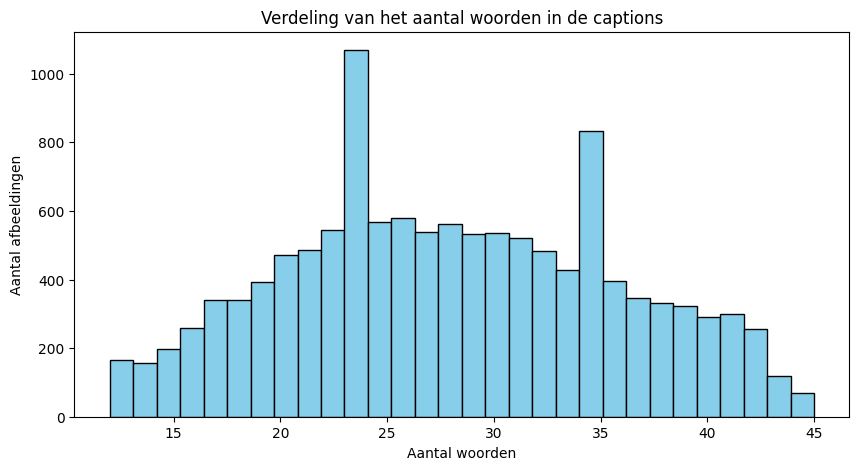


--- Voorbeelddata ---
                                                text  \
0  solid dark blue fitted top in soft stretch jer...   
1  melange dark grey trousers in sweatshirt fabri...   
2  solid black leggings in soft jersey with a wid...   
3  solid black short padded jacket with a jersey-...   
4  solid black harem trousers in jersey with elas...   

                                               image  word_count  
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...          16  
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...          23  
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...          27  
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...          37  
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...          13  


In [ ]:


# 2. Basis statistieken
print("--- Dataset Overzicht ---")
print(f"Totaal aantal items: {len(df)}")
print(f"Kolommen: {df.columns.tolist()}")

# 3. Tekstlengte analyse
# We berekenen het aantal woorden in de captions
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

print("\n--- Tekstlengte Statistieken ---")
print(df['word_count'].describe())

# 4. Visualisatie van tekstlengte
plt.figure(figsize=(10, 5))
plt.hist(df['word_count'], bins=30, color='skyblue', edgecolor='black')
plt.title('Verdeling van het aantal woorden in de captions')
plt.xlabel('Aantal woorden')
plt.ylabel('Aantal afbeeldingen')
plt.show()

# 5. Inspectie van de eerste paar rijen en afbeeldingen
print("\n--- Voorbeelddata ---")
print(df.head())

In [ ]:
from PIL import Image
import numpy as np

# Pak een klein steekproefje van de data
sample_size = 100
images = ds['train'].shuffle(seed=42).select(range(sample_size))["image"]

# Bereken de afmetingen
sizes = [img.size for img in images]
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f"Gemiddelde breedte: {np.mean(widths):.2f}")
print(f"Gemiddelde hoogte: {np.mean(heights):.2f}")
print(f"Min/Max afmetingen: {min(sizes)} tot {max(sizes)}")
print(f"Unieke afhoudingen (aantal): {len(set(sizes))}")

Gemiddelde breedte: 1204.20
Gemiddelde hoogte: 1749.97
Min/Max afmetingen: (450, 1750) tot (2328, 1749)
Unieke afhoudingen (aantal): 20


In [ ]:
# 1. Zorg dat je de dataset geladen hebt
# ds = load_dataset("tomytjandra/h-and-m-fashion-caption-12k")

# 2. Pak 10 willekeurige samples uit de training set
random_samples = ds['train'].shuffle(seed=42).select(range(10))

# 3. Print de teksten
for i, item in enumerate(random_samples):
    print(f"{i+1}: {item['text']}")

1: solid black trousers in a crepe weave with a low ribbed waistband and straight wide legs
2: solid black jumper in a soft fine-knit viscose blend with a deep v-neck long sleeves and ribbing around the neckline cuffs and hem
3: solid green ankle-length kaftan in a crepe weave with flounces down the sides and a v-neck with a wide flounced trim rounded hem with a flounced trim and short slits in the sides slightly shorter at the front
4: solid beige short fitted blouse in a cotton weave with shaping seams deep v-neck hook-and-eye fasteners at the front shoulder pads and short sleeves with a press-stud fastening
5: solid black jumper in fine-knit cotton with a round neck long sleeves chest pocket and ribbing around the neckline cuffs and hem
6: denim dark blue 5-pocket jeans in washed stretch cotton denim with hard-worn details in a looser fit with tapered legs wide jersey panel at the waist for best fit over the tummy the cotton content of the jeans is partly recycled
7: solid black tre

# Opdracht 3: Ondertiteling van afbeeldingen

 In deze deelopdracht werk je met de H&M images en captions dataset.

 Fine-tune een model om Engelse tekstbijschriften te genereren op basis van
afbeeldingen van kleding.

 Beschrijf in je eigen woorden hoe het model voorspellingen doet, welke lossfunctie
het gebruikt en hoe het wordt getraind.

 Onderbouw je keuzes van de hyperparameters, de keuze van de optimizer en het
aantal trainingsepochs

In [ ]:
import torch
from torch.optim import AdamW
from tqdm import tqdm
from transformers import AutoProcessor, BlipForConditionalGeneration
from peft import get_peft_model, LoraConfig, TaskType
from datasets import load_dataset

In [ ]:


# 1. Dataset inladen van Hugging Face
from datasets import load_dataset

# We voegen 'download_mode' toe om de cache te forceren en te vernieuwen
# en we printen wat er gebeurt
print("Dataset aan het laden...")
ds = load_dataset("tomytjandra/h-and-m-fashion-caption-12k")
print("Dataset geladen! Aantal voorbeelden:", len(ds["train"]))


Dataset aan het laden...


README.md:   0%|          | 0.00/323 [00:00<?, ?B/s]

Dataset geladen! Aantal voorbeelden: 12437


In [ ]:
from datasets import load_dataset

# Gebruik load_dataset in plaats van load_from_disk.
# Hugging Face herkent zelf de structuur in je cache-map.
dataset = load_dataset("tomytjandra/h-and-m-fashion-caption-12k")

print(dataset["train"].column_names)

['text', 'image']


In [ ]:
from torch.optim import AdamW

In [ ]:
# 3. Model & LoRA Setup
model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base", 
    use_safetensors=True
)
peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM, r=32, lora_alpha=64, lora_dropout=0.1,
    target_modules=["query", "key", "value", "output.dense"]
)
model = get_peft_model(model, peft_config)
model.to("cuda")

trainable params: 1,376,256 || all params: 3,876,920,832 || trainable%: 0.0355
Start training...


/home/beef/python312/lib/python3.14/site-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/home/beef/python312/lib/python3.14/site-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


KeyError: 'caption'

In [ ]:

# 4. Training
train_loader = torch.utils.data.DataLoader(processed_ds["train"], batch_size=16, shuffle=True)
optimizer = AdamW(model.parameters(), lr=5e-5)
model.train()

print("Start training...")
for epoch in range(3):
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
        optimizer.zero_grad()
        
        # Directe aanroep van base_model om de PEFT-wrapper interferentie te omzeilen
        outputs = model.base_model(
            pixel_values=batch["pixel_values"].to("cuda"),
            input_ids=batch["input_ids"].to("cuda"),
            attention_mask=batch["attention_mask"].to("cuda"),
            labels=batch["labels"].to("cuda")
        )
        
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
    print(f"Gemiddelde Loss epoch {epoch+1}: {total_loss / len(train_loader)}")

# Na training kun je het model opslaan:


Start training...


Epoch 1: 100%|██████████| 778/778 [06:09<00:00,  2.10it/s]


Gemiddelde Loss epoch 1: 4.47830482129879


Epoch 2: 100%|██████████| 778/778 [05:47<00:00,  2.24it/s]


Gemiddelde Loss epoch 2: 4.1800715926373835


Epoch 3: 100%|██████████| 778/778 [05:42<00:00,  2.27it/s]

Gemiddelde Loss epoch 3: 4.101669277200968


In [ ]:
model.save_pretrained("blip-hm-lora")

In [ ]:
from PIL import Image

In [ ]:


def generate_caption(image_path, model, processor):
    raw_image = Image.open(image_path).convert('RGB')
    
    inputs = processor(images=raw_image, return_tensors="pt").to("cuda")
    

    output = model.generate(**inputs, max_length=64, num_beams=5)
    
    caption = processor.decode(output[0], skip_special_tokens=True)
    return caption


test_image_path = "/home/beef/Downloads/a.jpg" 
result = generate_caption(test_image_path, model, processor)

print(f"Gegenereerde caption: {result}")

Gegenereerde caption: all over pattern light blue wide brimmed hat with a wide brimmed band at the top and a wide brimmed flower at the top


# 4


In [ ]:
aaaa

# Opdracht 4: Beeldgeneratie
 In deze deelopdracht werk je met de H&M images en captions dataset.

 Voor deze opdracht kies je een voorgetraind model van Hugging Face en fine-tune dit
op de afbeeldingen en tekstdataset.

 Geef de naam op van de modelarchitectuur die je hebt gekozen en de dataset
waarop deze vooraf is getraind.

 Je model moet een Engels tekstbijschrift als input gebruiken en een afbeelding als
output maken.

 Beschrijf in detail de stappen die worden genomen bij het finetunen van dit vooraf
getraind model.

 Beschrijf de componenten van dit model.

 Beschrijf in je eigen woorden hoe het model afbeeldingen maakt en welke lossfunctie
het gebruikt.

 Onderbouw je keuzes van de hyperparameters, de keuze van de optimizer en het
aantal trainingsepoch

# Opdracht 5: Implementatie

 Maak een eenvoudige app die een foto als input gebruikt, kledingstukken en
modeaccessoires detecteert en hun locatie geeft, en tekstbeschrijvingen genereert
van elk kledingstuk in de afbeelding. Gebruik de modellen die je in de voorgaande
opdrachten hebt getraind/gefinetuned.

 De app gebruikt een foto als input en voorspelt de locatie van elk afzonderlijk
kledingstuk en modeaccessoire. Vervolgens worden de individuele
kledingstukken/mode-items voorzien van bijschriften. De bijschriften moeten voor
elk afzonderlijk gedetecteerd item afzonderlijk worden gegenereerd.

 Let op: Je hoeft deze app niet te deployen. Je hoeft alleen maar de modellen in jouw
notebook uit te voeren en de voorspellingen op de juiste manier te combineren.

 Geef een samenvatting van de uitkomsten van het modelleren.
o Geef een beknopt overzicht van de resultaten.

o (Voor deel 1) Toon je scores op Kaggle en laat zien wat de resultaten waren
van je verbeteringen op je score op Kaggle.

o (Voor deel 2 & 3) Geef voorbeelden van je getrainde modellen in actie en
evalueer hun prestaties.

o Geef een voorbeeld/voorbeelden van hoe je app kleding en modeaccessoires
detecteert en geschikte bijschriften genereert voor elk gedetecteerd ite

# Opdracht 6: Conclusie en aanbevelingen
 Beschrijf het modelleringsproces voor deze opdracht. Wat waren de uitdagingen
daarmee?

 Wat zou je aanbevolen gebruik zijn van de modellen die je hebt getraind?

 Wat zouden je aanbevelingen zijn met betrekking tot het soort afbeeldingen/data
waarop je deze modellen kunt gebruiken?

 Zijn de resultaten van je modellen accuraat/betrouwbaar? Wat kan er gedaan
worden om deze te verbeteren?